In [1]:
# These modules are required for the data reduction.
from dysh.fits import GBTFITSLoad
from astropy import units as u
from dysh.log import init_logging

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="vane")

16:09:43.560 I Resolving example=vane -> fs-Argus/data/AGBT20B_295_02.raw.vegas/AGBT20B_295_02.raw.vegas.A.fits


16:09:43.561 I url: http://www.gb.nrao.edu/dysh//example_data/fs-Argus/data/AGBT20B_295_02.raw.vegas/AGBT20B_295_02.raw.vegas.A.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/fs-Argus/data/AGBT20B_295_02.raw.vegas/AGBT20B_295_02.raw.vegas.A.fits
AGBT20B_295_02.raw.vegas.A.fits already downloaded


In [4]:
sdfits = GBTFITSLoad(filename)

In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
10,VANE,65.0,Track,1,93.173777,1,1,25,2,166.9878,43.5400
11,SKY,65.0,Track,1,93.173777,1,1,25,2,166.9875,43.5399
12,G24.789,65.0,Track,1,93.173777,1,1,151,2,167.4363,43.6122


In [6]:
ta = sdfits.getfs(scan=12, ifnum=0, plnum=0, fdnum=10, vane=10).timeaverage()

16:09:43.810 I Vane calibrated data will be calibrated to Ta* units by default.


16:09:45.650 I Weather forecast not available.


16:09:45.950 I Ignoring 1 blanked integration(s).


16:09:46.146 I Vane temperature (twarm): 400.15 K


16:09:46.146 I No zenith opacity nor atmospheric temperature available. Will approximate the calibration temperature to the vane temperature 400.15 K


16:09:46.147 I Mean calibration temperature (tcal): 400.15 K


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


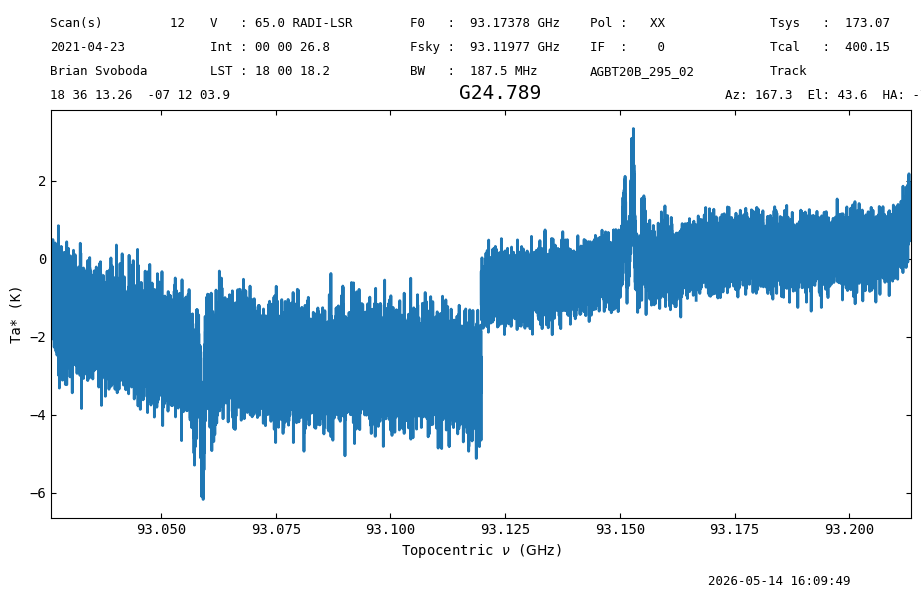

In [7]:
plot = ta.plot(xaxis_unit="GHz")

In [8]:
ta2 = sdfits.getfs(scan=12, ifnum=0, plnum=0, fdnum=10, vane=10,
                   zenith_opacity=0.01,
                   t_warm=583,
                   t_atm=260,
                   t_bkg=3,
                  ).timeaverage()

16:09:50.619 I Vane calibrated data will be calibrated to Ta* units by default.


16:09:51.393 I Weather forecast not available.


16:09:51.759 I Ignoring 1 blanked integration(s).


16:09:51.971 I Vane temperature (twarm): 583.00 K


16:09:51.972 I Mean calibration temperature (tcal): 584.97 K


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


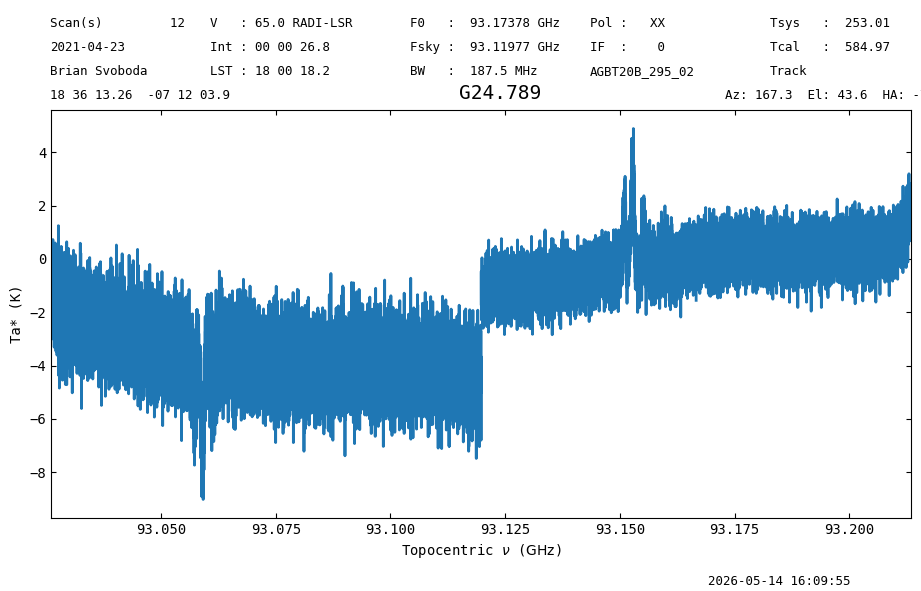

In [9]:
plot2 = ta2.plot(xaxis_unit="GHz")
plot2.oshow(ta)

In [10]:
print(ta.meta["TSYS"], ta2.meta["TSYS"])

173.0724666317342 253.01146158520933


In [11]:
ta3 = sdfits.getfs(scan=12, ifnum=0, plnum=0, fdnum=10, vane=10,
                   t_cal=584.97
                  ).timeaverage()

16:09:56.976 I Vane calibrated data will be calibrated to Ta* units by default.


16:09:57.751 I Weather forecast not available.


16:09:58.012 I Ignoring 1 blanked integration(s).


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


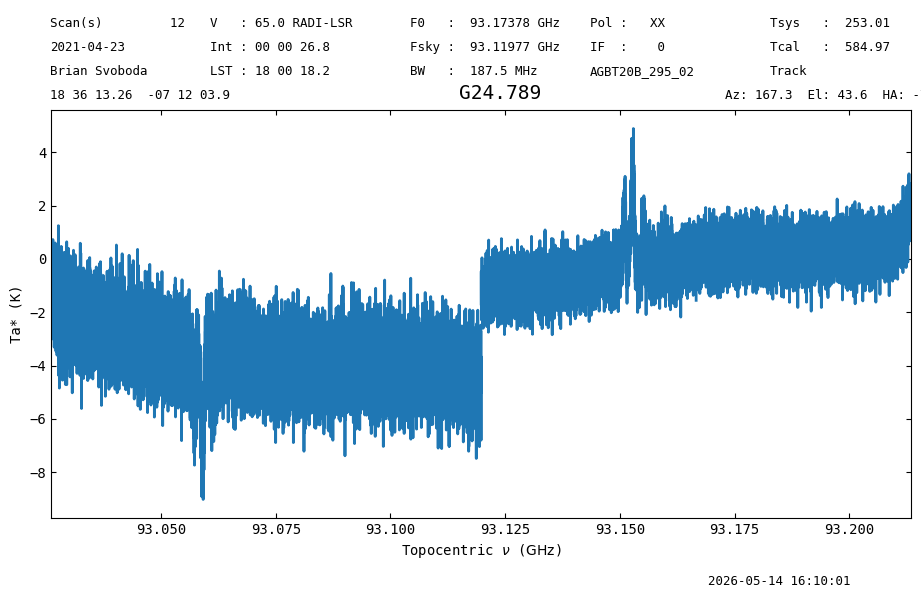

In [12]:
plot3 = ta3.plot(xaxis_unit="GHz")
plot3.oshow(ta2)

In [13]:
vane = sdfits.getvane(scan=10, ifnum=0, plnum=0, fdnum=10, 
                      zenith_opacity=0.01,
                      t_warm=583,
                      t_atm=260,
                      t_bkg=3)

16:10:03.978 I Weather forecast not available.


In [14]:
ref = sdfits.gettp(scan=11, ifnum=0, plnum=0, fdnum=10).timeaverage()

16:10:04.089 I Using TSYS column


In [15]:
vane.get_tcal(ref)

16:10:04.572 I Vane temperature (twarm): 583.00 K


16:10:04.574 I Mean calibration temperature (tcal): 584.98 K


np.float64(584.9782633701202)

In [16]:
vane.get_tsys(ref)

16:10:04.587 I Vane temperature (twarm): 583.00 K


16:10:04.588 I Mean calibration temperature (tcal): 584.98 K


np.float64(250.1676896502541)

16:10:04.596 I Vane calibrated data will be calibrated to Ta* units by default.


16:10:04.596 I Will use a zenith opacity of 0.01 nepers. Taken from vane.


16:10:04.870 I Ignoring 1 blanked integration(s).


16:10:05.072 I Vane temperature (twarm): 583.00 K


16:10:05.073 I Mean calibration temperature (tcal): 584.97 K


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/astropy/units/equivalencies.py:543: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 + beta) / (1 - beta)) - 1


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


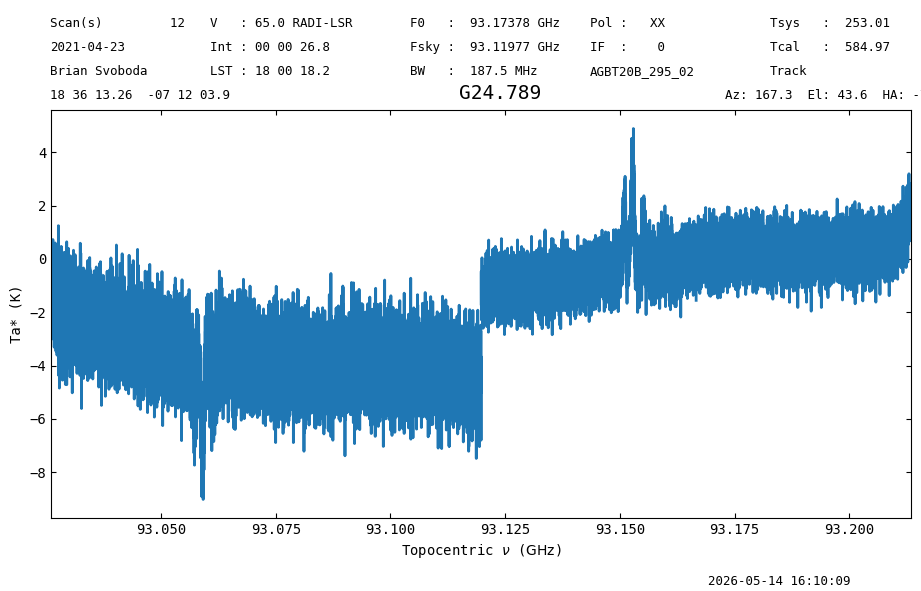

In [17]:
ta4 = sdfits.getfs(scan=12, ifnum=0, plnum=0, fdnum=10, vane=vane).timeaverage()
plot4 = ta4.plot(xaxis_unit="GHz")

In [18]:
ta4.check_stats(2.05290008 * u.K)

16:10:09.550 I rms is OK 


In [19]:
ta4[1500:8500].radiometer()

16:10:09.679 I Note: found 1 NaN (masked) values


np.float64(0.9100977688428993)